# Create the Data

Generated Time Series Data (first 5 rows):
            Value
Date             
2021-01-01  61.97
2021-02-01  65.39
2021-03-01  73.50
2021-04-01  81.68
2021-05-01  71.45


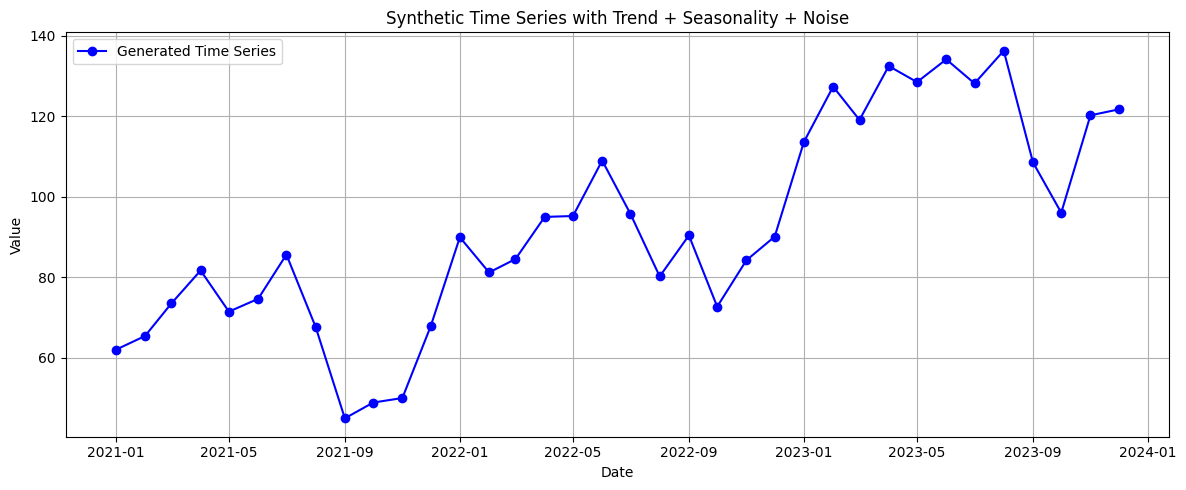

In [12]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Generate date range (e.g., 3 years of monthly data)
start_date = datetime(2021, 1, 1) 
dates = pd.date_range(start=start_date, freq='MS', periods=36) # 36 months

# Create base time index
t = np.arange(len(dates))

# ==================== Generate Components ====================

# 1. Trend (linear upward trend)
trend = 50 + 2.5 * t  # starts at 50, increases by 2.5 per month

# 2. Seasonality (yearly seasonality - stronger in summer)
seasonality = 20 * np.sin(2 * np.pi * t / 12) + 8 * np.cos(2 * np.pi * t / 6)

# 3. Noise (random variation)
noise = np.random.normal(loc=0, scale=8, size=len(t))

# ==================== Combine into Time Series ====================
y = trend + seasonality + noise

# Create DataFrame
df = pd.DataFrame({
    'Date': dates,
    'Value': y
})

# Make Date the index
df.set_index('Date', inplace=True)

# Round values for readability
df['Value'] = df['Value'].round(2)

print("Generated Time Series Data (first 5 rows):")
print(df.head())

# ==================== Plot the Data ====================
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Value'], label='Generated Time Series', color='blue', marker='o')
plt.title('Synthetic Time Series with Trend + Seasonality + Noise')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Time Series Concepts

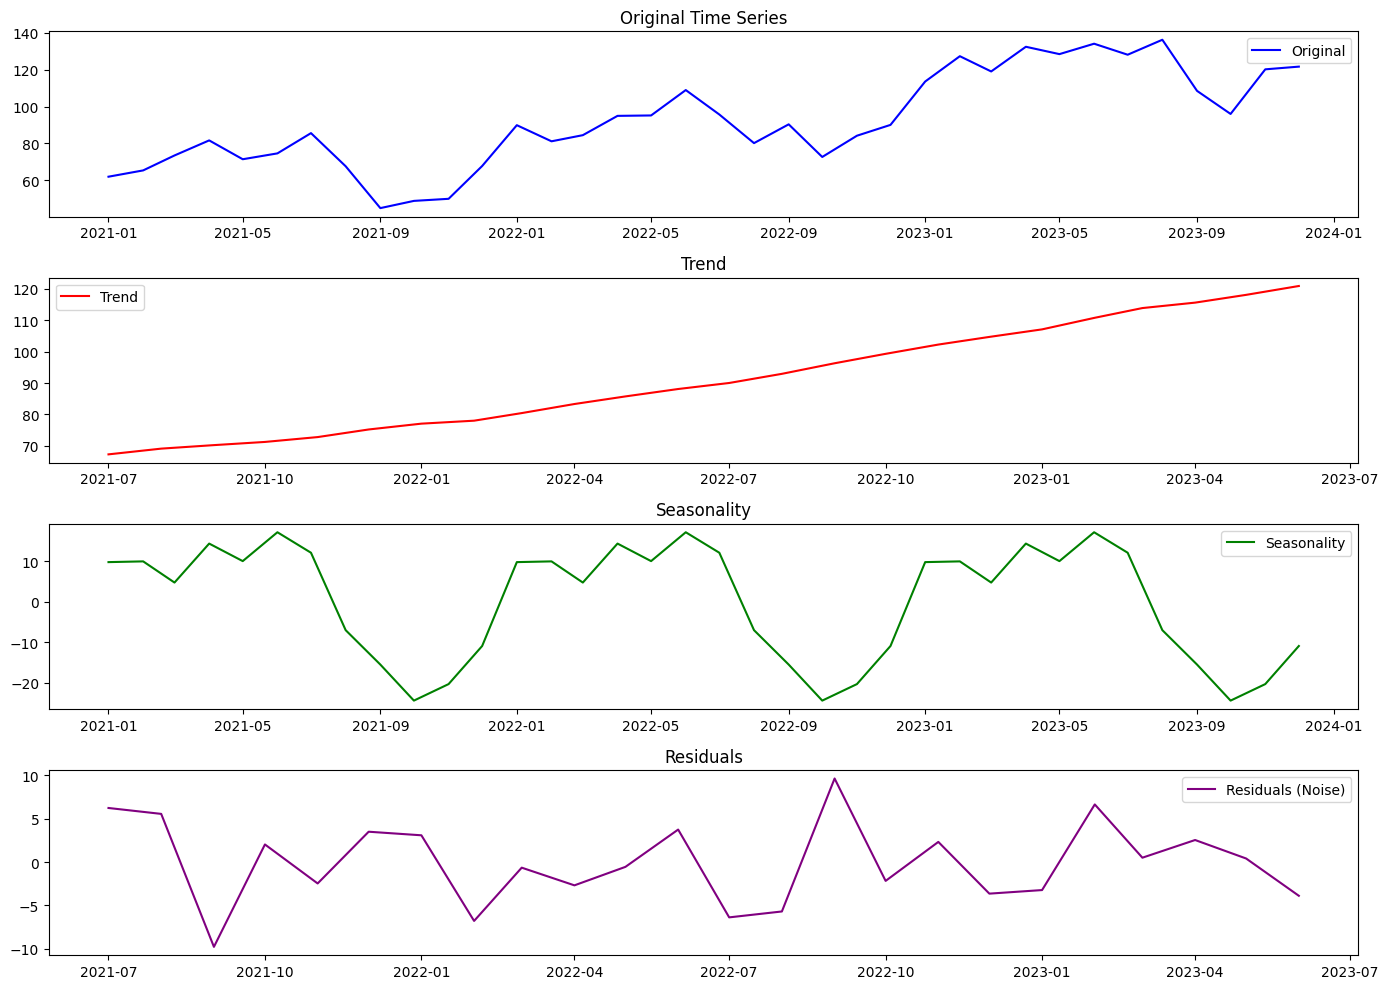

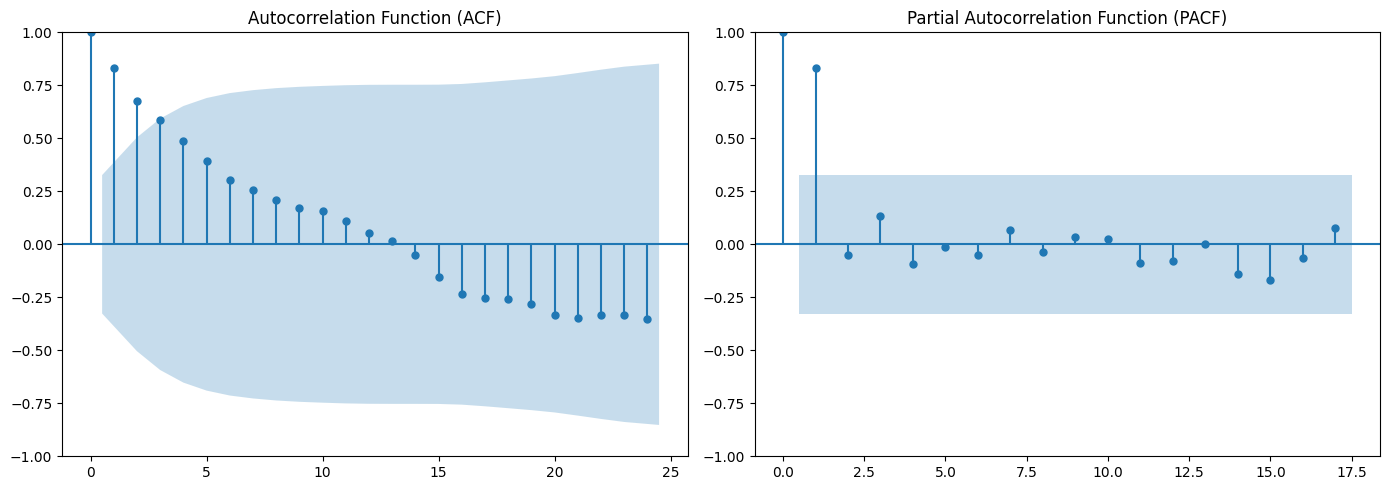


Testing Original Series:
=== Augmented Dickey-Fuller Test ===
ADF Statistic: 0.7297
p-value: 0.9904
Critical Values:
   1%: -3.7239
   5%: -2.9865
   10%: -2.6328

❌ Conclusion: The series is NON-STATIONARY


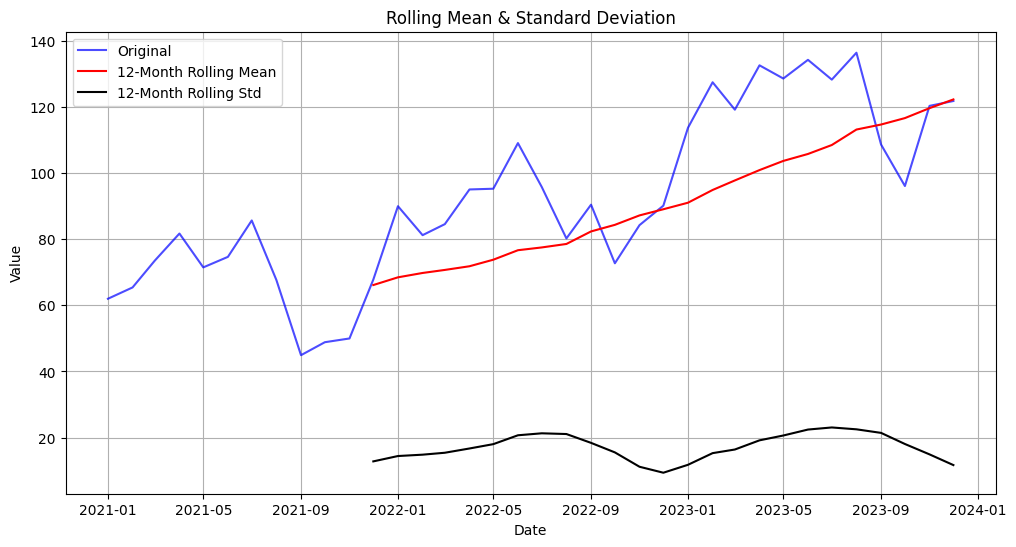

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# ==================== 1. Time Series Decomposition ====================
decomposition = seasonal_decompose(df['Value'], model='additive', period=12)

plt.figure(figsize=(14, 10))

plt.subplot(411)
plt.plot(df['Value'], label='Original', color='blue')
plt.title('Original Time Series')
plt.legend()

plt.subplot(412)
plt.plot(decomposition.trend, label='Trend', color='red')
plt.title('Trend')
plt.legend()

plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonality', color='green')
plt.title('Seasonality')
plt.legend()

plt.subplot(414)
plt.plot(decomposition.resid, label='Residuals (Noise)', color='purple')
plt.title('Residuals')
plt.legend()

plt.tight_layout()
plt.show()

# ==================== 2. ACF and PACF Plots ====================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(df['Value'], lags=24, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')

plot_pacf(df['Value'], lags=17, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

# ==================== 3. ADFuller Test for Stationarity ====================
def adf_test(series):
    result = adfuller(series, autolag='AIC')
    print("=== Augmented Dickey-Fuller Test ===")
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value:.4f}')
    
    if result[1] <= 0.05:
        print("\n✅ Conclusion: The series is STATIONARY")
    else:
        print("\n❌ Conclusion: The series is NON-STATIONARY")

print("\nTesting Original Series:")
adf_test(df['Value'])

# ==================== 4. Rolling Statistics ====================
window = 12
rolling_mean = df['Value'].rolling(window=window).mean()
rolling_std = df['Value'].rolling(window=window).std()

plt.figure(figsize=(12, 6))
plt.plot(df['Value'], label='Original', color='blue', alpha=0.7)
plt.plot(rolling_mean, label=f'{window}-Month Rolling Mean', color='red')
plt.plot(rolling_std, label=f'{window}-Month Rolling Std', color='black')
plt.title('Rolling Mean & Standard Deviation')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

## Baseline models

Mean Absolute Error (MAE) per model:
----------------------------------------
Naive               : 12.1525
SeasonalNaive       : 10.3625
HistoricAverage     : 37.6439
WindowAverage       : 10.0750


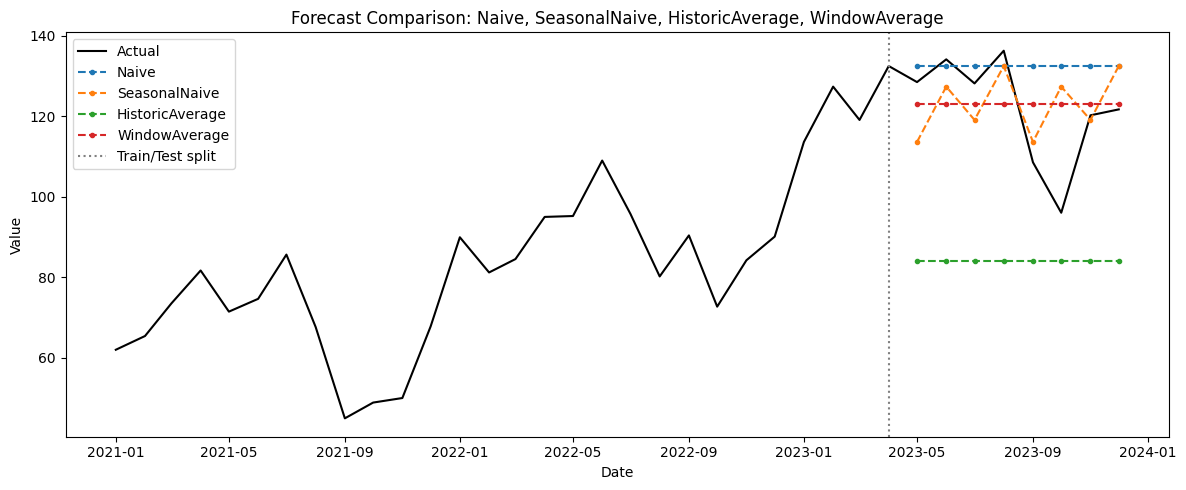

In [21]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, HistoricAverage, WindowAverage
from sklearn.metrics import mean_absolute_error

# ==================== 1. Prepare the data in the format StatsForecast expects ====================
df = df.reset_index().rename(columns={"Date": "ds", "Value": "y"}).copy()
df["ds"] = pd.to_datetime(df["ds"])
df["unique_id"] = "series_1"
df = df[["unique_id", "ds", "y"]].sort_values("ds").reset_index(drop=True)

# ==================== 2. Train / test split ====================
SEASON_LENGTH = 4      # change according to your data
HORIZON = 8            # number of periods to forecast / size of the test set
train_df = df.iloc[:-HORIZON]
test_df = df.iloc[-HORIZON:]


# ==================== 3. Define and fit the models ====================
models = [
    Naive(),
    SeasonalNaive(season_length=SEASON_LENGTH),
    HistoricAverage(),
    WindowAverage(window_size=SEASON_LENGTH),
]

sf = StatsForecast(
    models=models,
    freq="MS",
    n_jobs=-1,
)

sf.fit(train_df)


# ==================== 4. Forecast ====================
forecast_df = sf.predict(h=HORIZON)

# Merge forecasts with actual test values for comparison
results = forecast_df.merge(test_df, on=["unique_id", "ds"], how="left")


# ==================== 5. Calculate MAE for each model ====================
model_names = [m.__class__.__name__ for m in models]
# statsforecast may alias names differently (e.g. WindowAverage -> "WindowAverage")
model_cols = [c for c in forecast_df.columns if c not in ("unique_id", "ds")]

print("Mean Absolute Error (MAE) per model:")
print("-" * 40)
mae_scores = {}
for col in model_cols:
    mae = mean_absolute_error(results["y"], results[col])
    mae_scores[col] = mae
    print(f"{col:20s}: {mae:.4f}")


# ==================== 6. Plot actual vs forecasted values ====================
plt.figure(figsize=(12, 5))

# Plot full history (train + test) for context
plt.plot(df["ds"], df["y"], label="Actual", color="black", linewidth=1.5)

# Plot each model's forecast
for col in model_cols:
    plt.plot(results["ds"], results[col], label=col, linestyle="--", marker="o", markersize=3)

plt.axvline(train_df["ds"].iloc[-1], color="gray", linestyle=":", label="Train/Test split")
plt.title("Forecast Comparison: Naive, SeasonalNaive, HistoricAverage, WindowAverage")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

# ARIMA

Mean Absolute Error (MAE)
----------------------------------------
AutoARIMA           : 13.0647


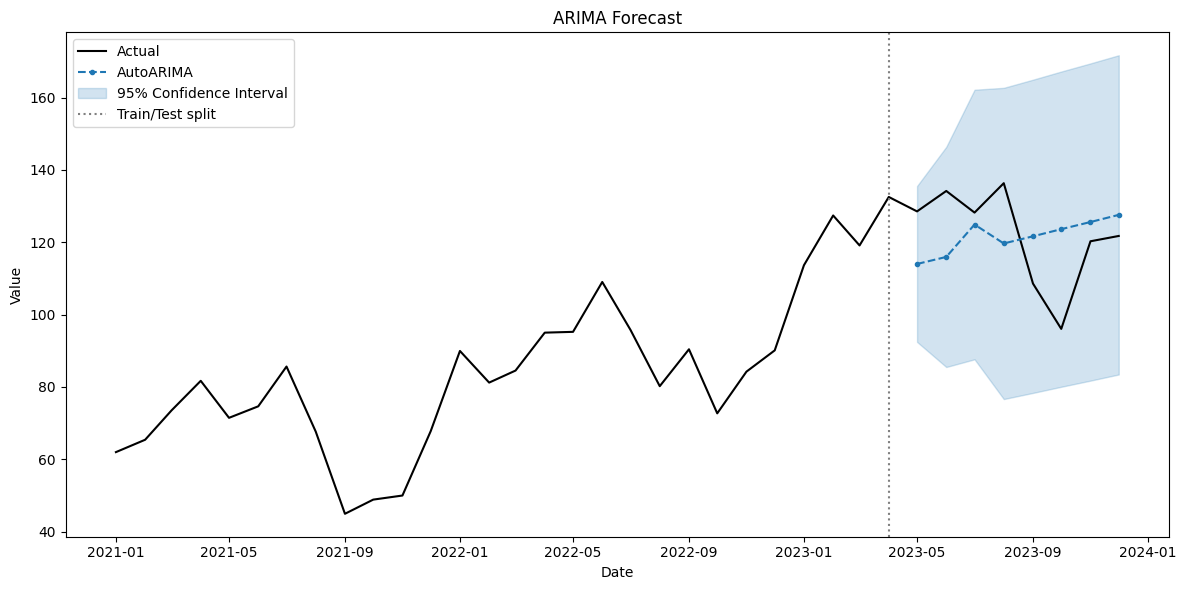

In [28]:
from statsforecast.models import AutoARIMA


# ==================== 1. Train / test split ====================
SEASON_LENGTH = 4      # monthly data -> 12 months per year (yearly seasonality)
HORIZON = 8            # number of months to forecast / size of the test set

train_df = df.iloc[:-HORIZON][["unique_id", "ds", "y"]]
test_df = df.iloc[-HORIZON:][["unique_id", "ds", "y"]]

# ----------------------------------------------------------------------
# 2. Define and fit AutoARIMA
#    AutoARIMA automatically searches over (p, d, q)(P, D, Q) orders and
#    picks the best one based on information criteria (AICc by default).
# ----------------------------------------------------------------------
models = [
    AutoARIMA(season_length=SEASON_LENGTH),
]

sf = StatsForecast(
    models=models,
    freq="MS",
    n_jobs=-1,
)

sf.fit(train_df)

# ==================== 3. Forecast (with confidence intervals) ====================

forecast_df = sf.predict(h=HORIZON, level=[95])

# Merge forecasts with actual test values for comparison
results = forecast_df.merge(test_df, on=["unique_id", "ds"], how="left")

# ==================== 4. Calculate MAE ====================
model_col = "AutoARIMA"   # the point-forecast column name

valid = results[["y", model_col]].dropna()
mae = mean_absolute_error(valid["y"], valid[model_col])

print("Mean Absolute Error (MAE)")
print("-" * 40)
print(f"{model_col:20s}: {mae:.4f}")

# ==================== 5. Plot actual vs forecasted values (with 95% confidence interval) ====================
plt.figure(figsize=(12, 6))

# Full history, using the original (real) dates
plt.plot(df["ds"], df["y"], label="Actual", color="black", linewidth=1.5)

# ARIMA point forecast
plt.plot(
    results["ds"], results[model_col],
    label=model_col, linestyle="--", marker="o", markersize=3, color="tab:blue",
)

# 95% confidence interval band
lo_col = f"{model_col}-lo-95"
hi_col = f"{model_col}-hi-95"
if lo_col in results.columns and hi_col in results.columns:
    plt.fill_between(
        results["ds"], results[lo_col], results[hi_col],
        color="tab:blue", alpha=0.2, label="95% Confidence Interval",
    )

plt.axvline(df["ds"].iloc[-HORIZON - 1], color="gray", linestyle=":", label="Train/Test split")
plt.title("ARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

# Using Cross Validation in Forecasting


Cross-validation results (first few rows):
  unique_id         ds     cutoff      y  AutoARIMA  AutoARIMA-lo-95  \
0  series_1 2022-01-01 2021-12-01  89.94      44.92         5.965598   
1  series_1 2022-02-01 2021-12-01  81.19      48.84         9.885598   
2  series_1 2022-03-01 2021-12-01  84.52      49.97        11.015598   
3  series_1 2022-04-01 2021-12-01  95.00      67.77        28.815598   
4  series_1 2022-05-01 2021-12-01  95.22      44.92       -10.169844   

   AutoARIMA-hi-95  
0        83.874402  
1        87.794402  
2        88.924402  
3       106.724402  
4       100.009844  

Mean Absolute Error (MAE) per cross-validation fold:
----------------------------------------
cutoff = 2021-12-01 : MAE = 38.4775
cutoff = 2022-08-01 : MAE = 27.8521
cutoff = 2023-04-01 : MAE = 13.0647
----------------------------------------
Overall CV MAE (across all folds): 26.4648


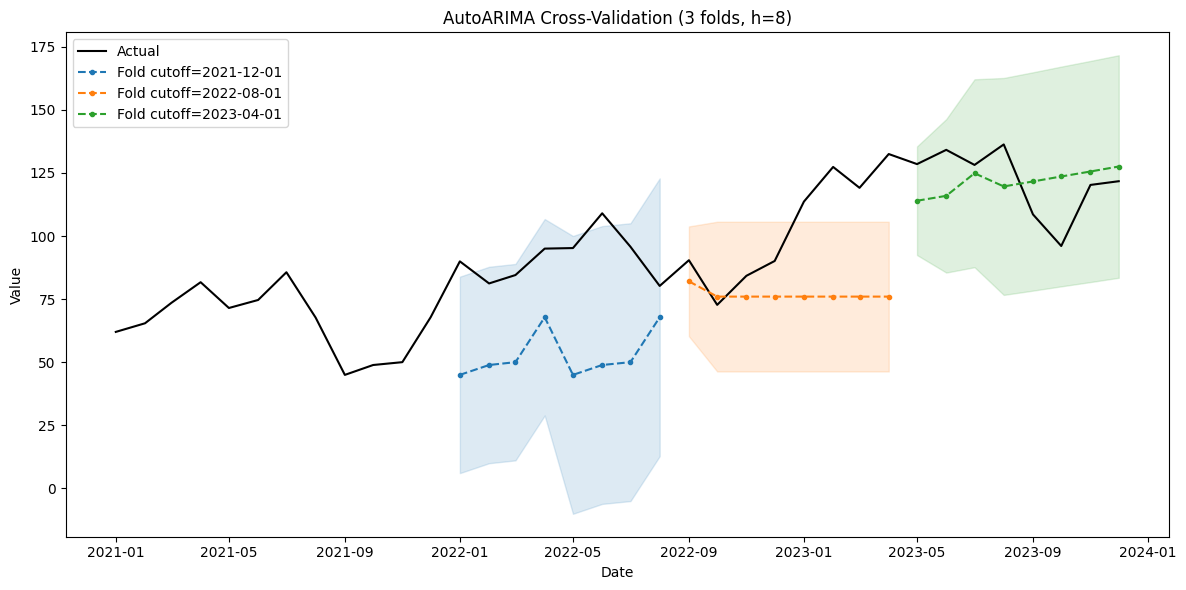

In [ ]:
N_WINDOWS = 3 
STEP_SIZE = HORIZON

# cross_validation is run on the FULL df (not train_df), since it internally
# handles the rolling splits itself.
cv_df = sf.cross_validation(
    df=df[["unique_id", "ds", "y"]],
    h=HORIZON,
    step_size=STEP_SIZE,
    n_windows=N_WINDOWS,
    level=[95],
)

print("\nCross-validation results (first few rows):")
print(cv_df.head())

# ----------------------------------------------------------------------
#  MAE per fold and overall, from cross-validation
# ----------------------------------------------------------------------
cv_df["abs_error"] = (cv_df["y"] - cv_df[model_col]).abs()

mae_per_fold = cv_df.groupby("cutoff")["abs_error"].mean()
overall_cv_mae = cv_df["abs_error"].mean()

print("\nMean Absolute Error (MAE) per cross-validation fold:")
print("-" * 40)
for cutoff, fold_mae in mae_per_fold.items():
    print(f"cutoff = {cutoff.date()} : MAE = {fold_mae:.4f}")

print("-" * 40)
print(f"Overall CV MAE (across all folds): {overall_cv_mae:.4f}")

# ----------------------------------------------------------------------
# Plot cross-validation folds against the actual series
# ----------------------------------------------------------------------
plt.figure(figsize=(12, 6))
plt.plot(df["ds"], df["y"], label="Actual", color="black", linewidth=1.5)

colors = plt.cm.tab10.colors
for i, (cutoff, fold_df) in enumerate(cv_df.groupby("cutoff")):
    color = colors[i % len(colors)]
    plt.plot(
        fold_df["ds"], fold_df[model_col],
        linestyle="--", marker="o", markersize=3, color=color,
        label=f"Fold cutoff={cutoff.date()}",
    )
    lo_col = f"{model_col}-lo-95"
    hi_col = f"{model_col}-hi-95"
    if lo_col in fold_df.columns and hi_col in fold_df.columns:
        plt.fill_between(fold_df["ds"], fold_df[lo_col], fold_df[hi_col], color=color, alpha=0.15)

plt.title(f"AutoARIMA Cross-Validation ({N_WINDOWS} folds, h={HORIZON})")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

## Prophet Module
- One of the best and easiest models in forecasting, designed for working on real data
- can work with null values, outliers and surprising changes in trend and multiple seasonality
- splits the time series to: Trend, Seasonality, Holidays and Error

22:17:21 - cmdstanpy - INFO - Chain [1] start processing
22:17:21 - cmdstanpy - INFO - Chain [1] done processing


Mean Absolute Error (MAE) - Prophet
----------------------------------------
Prophet             : 24.4797


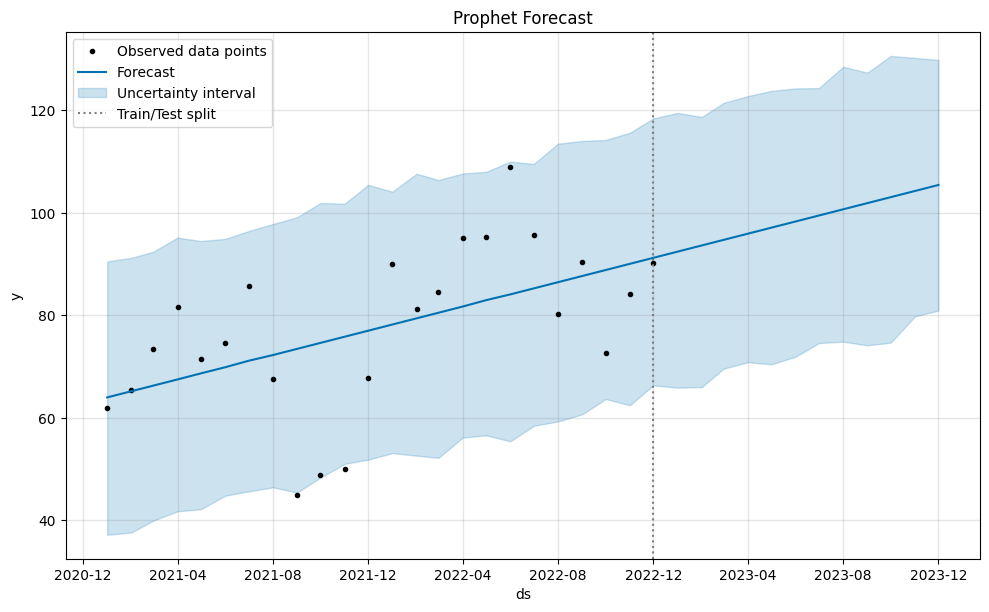

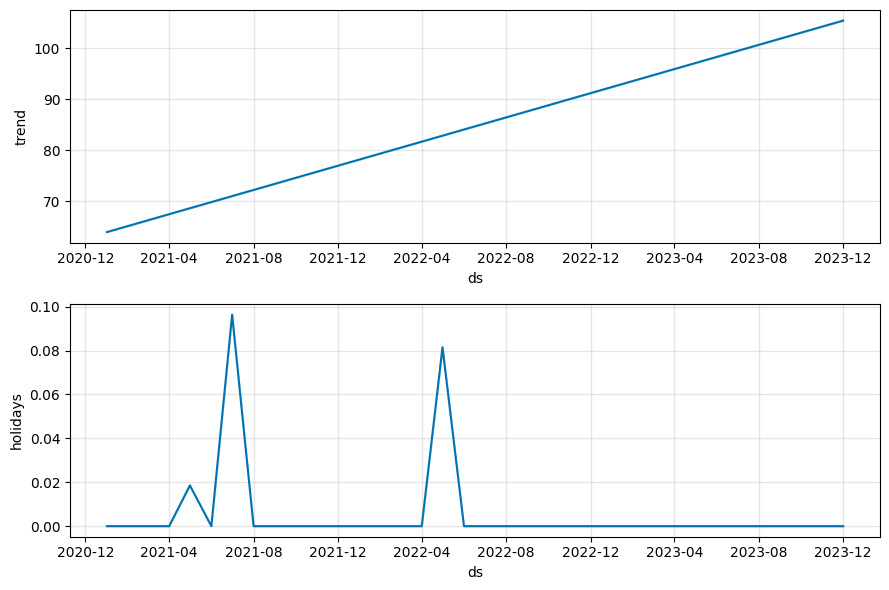

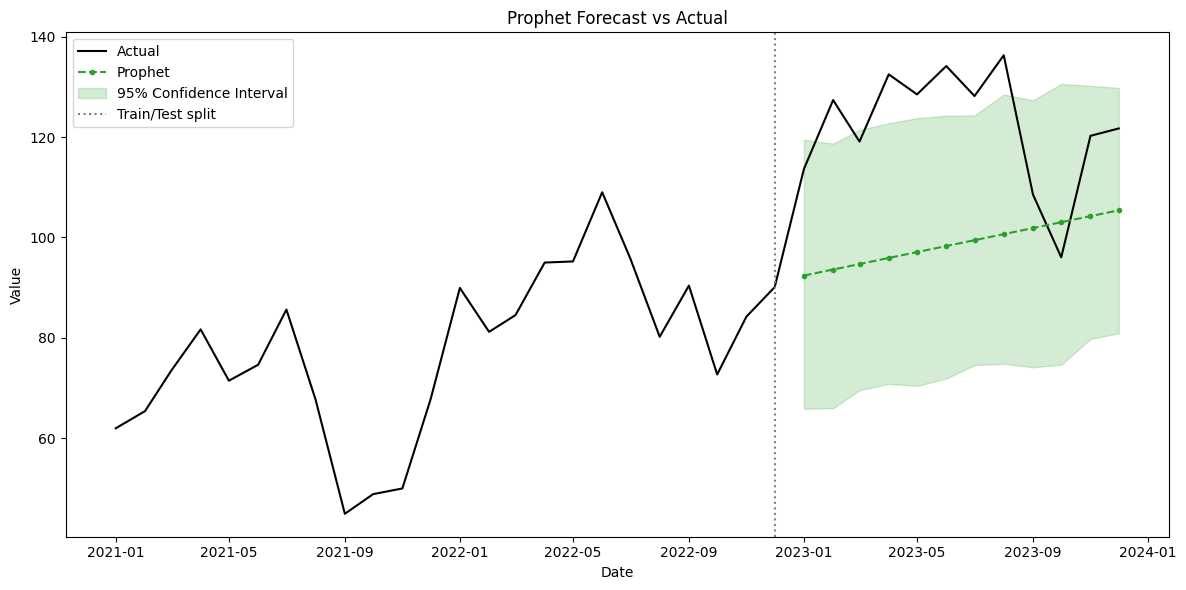

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_absolute_error

# ==================== 1. Train / test split ====================
HORIZON = 12   # number of months to forecast / size of the test set

train_df = df.iloc[:-HORIZON][["ds", "y"]]
test_df = df.iloc[-HORIZON:][["ds", "y"]]

# ==================== 2. Define and fit Prophet ====================
ph = Prophet(
    growth='linear',                # the form of trend (linear, logistic)
    changepoint_prior_scale=0.01,   # the trend flexibility
    seasonality_prior_scale=5,      # the seasonality effect power
    holidays_prior_scale=0.01,      # the holidays effect power
    yearly_seasonality=False,       # yearly activate
    weekly_seasonality=False,       # weekly activate
    daily_seasonality=False,        # daily activate
    seasonality_mode='additive',    # the seasonality type (additive, multiplicative)
    interval_width=0.95             # show the confidence interval
)

# add an egyptian holidays
ph.add_country_holidays(country_name='EG')

# IMPORTANT: fit only on the training data, not the full df, so the test
# period is truly unseen and the MAE reflects genuine out-of-sample error.
ph.fit(train_df)

# ==================== 3. Forecast ====================
# predict the next HORIZON months (covers exactly the held-out test period)
future = ph.make_future_dataframe(periods=HORIZON, freq="MS")
forecast = ph.predict(future)

# ==================== 4. Calculate MAE ====================
# Keep only the forecasted rows that fall in the test period, then merge
# with the actual held-out values.
forecast_test = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    test_df, on="ds", how="inner"
)

valid = forecast_test[["y", "yhat"]].dropna()
mae = mean_absolute_error(valid["y"], valid["yhat"])

print("Mean Absolute Error (MAE) - Prophet")
print("-" * 40)
print(f"{'Prophet':20s}: {mae:.4f}")

# ==================== 5. Plot the results ====================
# Prophet's own built-in plots (full forecast, including future beyond test)
fig1 = ph.plot(forecast)
plt.title("Prophet Forecast")
plt.axvline(train_df["ds"].iloc[-1], color="gray", linestyle=":", label="Train/Test split")
plt.legend()
plt.show()

fig2 = ph.plot_components(forecast)
plt.show()

# A focused actual-vs-forecast plot on just the test period, matching the
# style used for the other models (Naive, ARIMA, etc.)
plt.figure(figsize=(12, 6))
plt.plot(df["ds"], df["y"], label="Actual", color="black", linewidth=1.5)
plt.plot(
    forecast_test["ds"], forecast_test["yhat"],
    label="Prophet", linestyle="--", marker="o", markersize=3, color="tab:green",
)
plt.fill_between(
    forecast_test["ds"], forecast_test["yhat_lower"], forecast_test["yhat_upper"],
    color="tab:green", alpha=0.2, label="95% Confidence Interval",
)
plt.axvline(train_df["ds"].iloc[-1], color="gray", linestyle=":", label="Train/Test split")
plt.title("Prophet Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

## ML in Forecasting

Mean Absolute Error (MAE) - XGBoost (recursive forecast)
----------------------------------------
XGBoost             : 33.3711


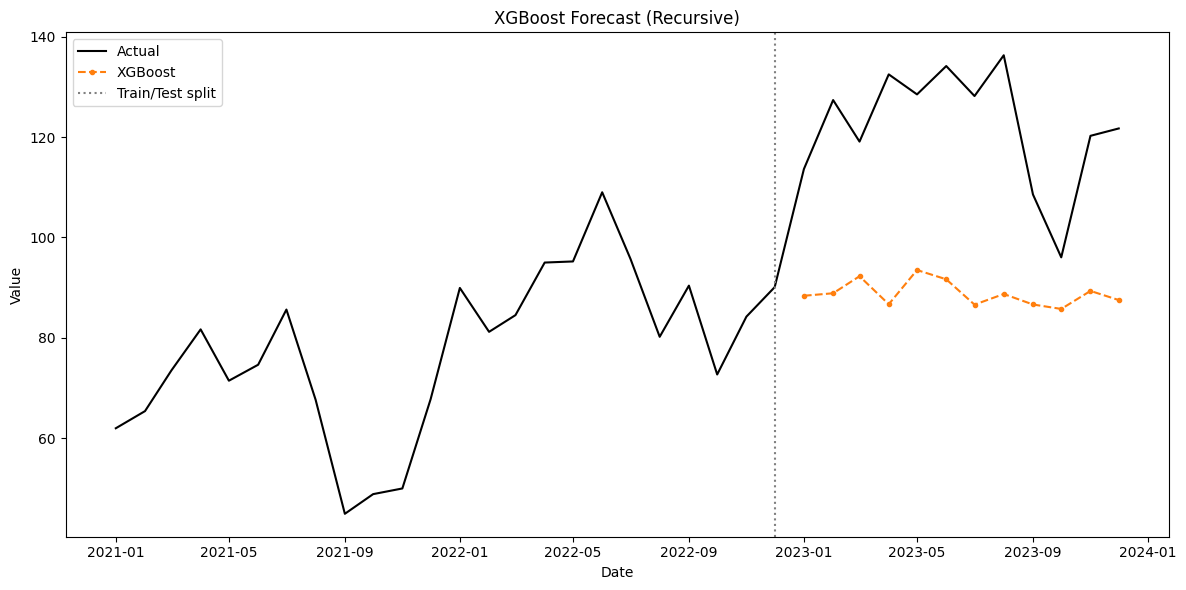

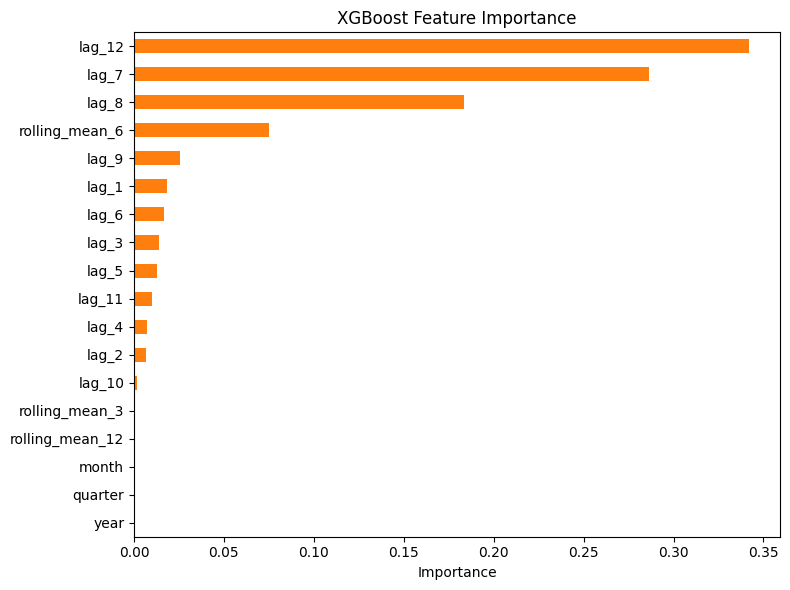

In [50]:
from xgboost import XGBRegressor

# ==================== 1. Settings ====================
HORIZON = 12          # months to forecast / hold out as test set
N_LAGS = 12           # how many past months to use as lag features
ROLLING_WINDOWS = [3, 6, 12]  # rolling-mean window sizes (in months) as extra features

data = df[["ds", "y"]].sort_values("ds").reset_index(drop=True).copy()

# ==================== 2. Feature engineering ====================
# Lag features: y(t-1), y(t-2), ..., y(t-N_LAGS)
for lag in range(1, N_LAGS + 1):
    data[f"lag_{lag}"] = data["y"].shift(lag)

# Rolling mean features (computed on lagged data, so no leakage from the
# current/future value into the feature)
for w in ROLLING_WINDOWS:
    data[f"rolling_mean_{w}"] = data["y"].shift(1).rolling(window=w).mean()

# Calendar features
data["month"] = data["ds"].dt.month
data["quarter"] = data["ds"].dt.quarter
data["year"] = data["ds"].dt.year

feature_cols = (
    [f"lag_{lag}" for lag in range(1, N_LAGS + 1)]
    + [f"rolling_mean_{w}" for w in ROLLING_WINDOWS]
    + ["month", "quarter", "year"]
)

# Drop rows with NaN features (the first N_LAGS/max(ROLLING_WINDOWS) rows,
# where there isn't enough history yet)
data_model = data.dropna().reset_index(drop=True)

# ==================== 3. Train / test split ====================
# Keep the last HORIZON rows (of the feature-complete data) as the test set.
train_data = data_model.iloc[:-HORIZON]
test_data = data_model.iloc[-HORIZON:]

X_train, y_train = train_data[feature_cols], train_data["y"]
X_test, y_test = test_data[feature_cols], test_data["y"]

# ==================== 4. Fit XGBoost ====================
model = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

model.fit(X_train, y_train)

# ==================== 5. Recursive multi-step forecast ====================
# We forecast HORIZON steps ahead one at a time: predict the next value,
# append it to the history, recompute lag/rolling features, then predict
# the step after that. This mirrors how the model would be used in
# production (no access to future actuals).
history = data.iloc[: len(data) - HORIZON][["ds", "y"]].copy()
future_dates = data.iloc[len(data) - HORIZON :]["ds"].reset_index(drop=True)

preds = []
for step_date in future_dates:
    row = {}
    for lag in range(1, N_LAGS + 1):
        row[f"lag_{lag}"] = history["y"].iloc[-lag]
    for w in ROLLING_WINDOWS:
        row[f"rolling_mean_{w}"] = history["y"].iloc[-w:].mean()
    row["month"] = step_date.month
    row["quarter"] = step_date.quarter
    row["year"] = step_date.year

    X_next = pd.DataFrame([row])[feature_cols]
    y_next = model.predict(X_next)[0]
    preds.append(y_next)

    # append the prediction to history so it becomes available as a lag
    # for forecasting the following step
    history = pd.concat(
        [history, pd.DataFrame({"ds": [step_date], "y": [y_next]})],
        ignore_index=True,
    )

results = pd.DataFrame({"ds": future_dates, "y": test_data["y"].values, "XGBoost": preds})

# ==================== 6. Calculate MAE ====================
mae = mean_absolute_error(results["y"], results["XGBoost"])

print("Mean Absolute Error (MAE) - XGBoost (recursive forecast)")
print("-" * 40)
print(f"{'XGBoost':20s}: {mae:.4f}")

# ==================== 7. Plot actual vs forecasted values ====================
plt.figure(figsize=(12, 6))
plt.plot(data["ds"], data["y"], label="Actual", color="black", linewidth=1.5)
plt.plot(
    results["ds"], results["XGBoost"],
    label="XGBoost", linestyle="--", marker="o", markersize=3, color="tab:orange",
)
plt.axvline(data["ds"].iloc[-HORIZON - 1], color="gray", linestyle=":", label="Train/Test split")
plt.title("XGBoost Forecast (Recursive)")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

# ==================== 8. Feature importance ====================
importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importance.plot(kind="barh", color="tab:orange")
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()